# Project Checkpoint 1: Dataset Selection and Exploratory Data Analysis
**Course:** CSCE 676: Data Mining & Analysis \
**Topic:** Analyzing Consumer Sentiment and Product Associations

## Project Overview
This notebook documents the selection of a dataset for the semester-long data mining project. It includes an evaluation of three candidate datasets, a comparative analysis, and initial exploratory data analysis (EDA) on the chosen dataset.

## (A) Identification of Candidate Datasets

### 1. 20 Newsgroups Dataset (Selected)
*   **Source:** Scikit-Learn Built-in Library
*   **Course Topic Alignment:** Text Mining (TF-IDF, Feature Extraction), Clustering (K-Means).
*   **Potential Beyond-Course Techniques:** **Latent Dirichlet Allocation (LDA)** for Topic Modeling and **Word2Vec** for semantic embeddings.
*   **Dataset Size and Structure:** ~18,846 newsgroup posts across 20 topics.
*   **Data Types:** Raw Text (String), Topic Label (Integer).
*   **Target Variables:** Newsgroup Category (e.g., 'sci.space', 'rec.sport.hockey').
*   **Licensing:** Public Domain / Open Access.

### 2. Online Retail Transaction Logs
*   **Source:** [UCI Machine Learning Repository](https://archive.ics.uci.edu/ml/datasets/Online+Retail)
*   **Course Topic Alignment:** Frequent Itemsets and Association Rule Mining (Apriori, FP-Growth).
*   **Potential Beyond-Course Techniques:** **Sequential Pattern Mining (PrefixSpan)** to analyze the temporal order of customer purchases.
*   **Dataset Size and Structure:** 541,909 transactions (CSV).
*   **Data Types:** InvoiceNo (ID), StockCode (String), Quantity (Int), CustomerID (Float).
*   **Target Variables:** None (Unsupervised pattern mining).
*   **Licensing:** CC BY 4.0.

### 3. Twitch Social Network Graph
*   **Source:** [SNAP Social Computing Data](https://snap.stanford.edu/data/twitch_gamers.html)
*   **Course Topic Alignment:** Graph Mining (PageRank, Community Detection, Centrality).
*   **Potential Beyond-Course Techniques:** **Link Prediction** using Graph Neural Networks (GNNs).
*   **Dataset Size and Structure:** 168k nodes, 6.7M edges (Adjacency List).
*   **Data Types:** Node IDs (Int), Binary flags (Mature content), Views (Int).
*   **Target Variables:** Mature Content Flag (Binary).
*   **Licensing:** Public Domain.

## (B) Comparative Analysis of Datasets

| Dimension | 20 Newsgroups (Text) | Online Retail (Logs) | Twitch Graph (Network) |
| :--- | :--- | :--- | :--- |
| **Data Mining Tasks** | **Course:** Text Mining, Clustering. <br>**External:** LDA Topics. | **Course:** Association Rules. <br>**External:** Seq. Patterns. | **Course:** Centrality, Community. <br>**External:** Node Embeddings. |
| **Data Quality Issues** | Noisy text (ASCII art, old headers), empty posts. | High sparsity (most items rarely bought together), missing Customer IDs. | High skewness; celebrity streamers create "super-nodes" that bias metrics. |
| **Algorithmic Feasibility**| **High.** Fits in memory; TF-IDF is computationally cheap. | **Medium.** Apriori scales poorly with low support thresholds. | **Low.** PageRank on 6M edges is slow without Spark/distributed computing. |
| **Bias Considerations** | Historical bias; reflects internet culture from the mid-90s. | Popularity bias; rules will only reflect the top 1% of best-sellers. | Sampling bias; only represents Twitch users, not the general population. |
| **Ethical Considerations** | Personal identifiers (emails) in old news posts. | Tracking of consumer habits and potential price discrimination. | Influence mapping and deanonymization of social connections. |

## (C) Dataset Selection: 20 Newsgroups

**Selected Dataset:** 20 Newsgroups

**Justification:**
I have selected the **20 Newsgroups** dataset for several strategic reasons:
1.  **Direct Course Alignment:** It provides a robust foundation for **Text Mining** and **Clustering**, which are central to the course curriculum.
2.  **Beyond-Course Potential:** It is the ideal dataset for **Latent Dirichlet Allocation (LDA)**. Unlike the Retail data, which is purely transactional, or the Twitch data, which is purely topological, text allows for semantic discovery that I am interested in exploring.
3.  **Experimental Control:** Because the data is already categorized into 20 newsgroups, I have a "ground truth" labels to measure the success of my unsupervised clustering algorithms.
4.  **Manageability:** Compared to the Twitch graph (which might require specialized hardware for link prediction), the Newsgroups data is manageable on a standard machine while still being "real-world" enough to present challenges.

**Trade-offs:**
*   **Temporal Gap:** The data doesn't reflect modern language trends.
*   **No Temporal Flow:** Unlike the Retail dataset, this is a "snapshot" and does not allow for sequential purchase behavior analysis.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_20newsgroups

# Set style
sns.set_theme(style="whitegrid")

# Fetch the dataset (we take all categories to ensure a rich dataset)
print("Loading 20 Newsgroups dataset from local library...")
newsgroups = fetch_20newsgroups(subset='all', remove=('headers', 'footers', 'quotes'))

# Convert to a Pandas DataFrame for professional handling
df = pd.DataFrame({
    'text': newsgroups.data,
    'target': newsgroups.target
})

# Map numeric targets to actual category names
df['category'] = df['target'].apply(lambda x: newsgroups.target_names[x])

print("Dataset loaded successfully!")
print(f"Total records: {df.shape[0]}")
df.head()

Loading 20 Newsgroups dataset from local library...
Dataset loaded successfully!
Total records: 18846


,text,target,category
0,\n\nI am sure some bashers of Pens fans are pr...,10,rec.sport.hockey
1,My brother is in the market for a high-perform...,3,comp.sys.ibm.pc.hardware
2,\n\n\n\n\tFinally you said what you dream abou...,17,talk.politics.mideast
3,\nThink!\n\nIt's the SCSI card doing the DMA t...,3,comp.sys.ibm.pc.hardware
4,1) I have an old Jasmine drive which I cann...,4,comp.sys.mac.hardware


In [2]:
# 1. Handle Empty Reviews
# Decision: Some posts are empty after removing headers/footers. We remove them.
# Reasoning: You cannot perform text mining or LDA on empty strings.
df['text_len'] = df['text'].str.strip().str.len()
df = df[df['text_len'] > 0]

# 2. Check for missing values
print("Missing values check:\n", df.isnull().sum())

# 3. Decision: Basic text normalization
# We lowercase everything to ensure that 'Space' and 'space' are treated the same.
df['text'] = df['text'].str.lower()

# 4. Remove duplicates
# Reasoning: Newsgroup threads often contain reposts.
# Removing duplicates ensures our frequent itemsets/clusters aren't biased.
df = df.drop_duplicates(subset=['text'])

print(f"Cleaned dataset size: {df.shape}")

Missing values check:
 text        0
target      0
category    0
text_len    0
dtype: int64
Cleaned dataset size: (18270, 4)


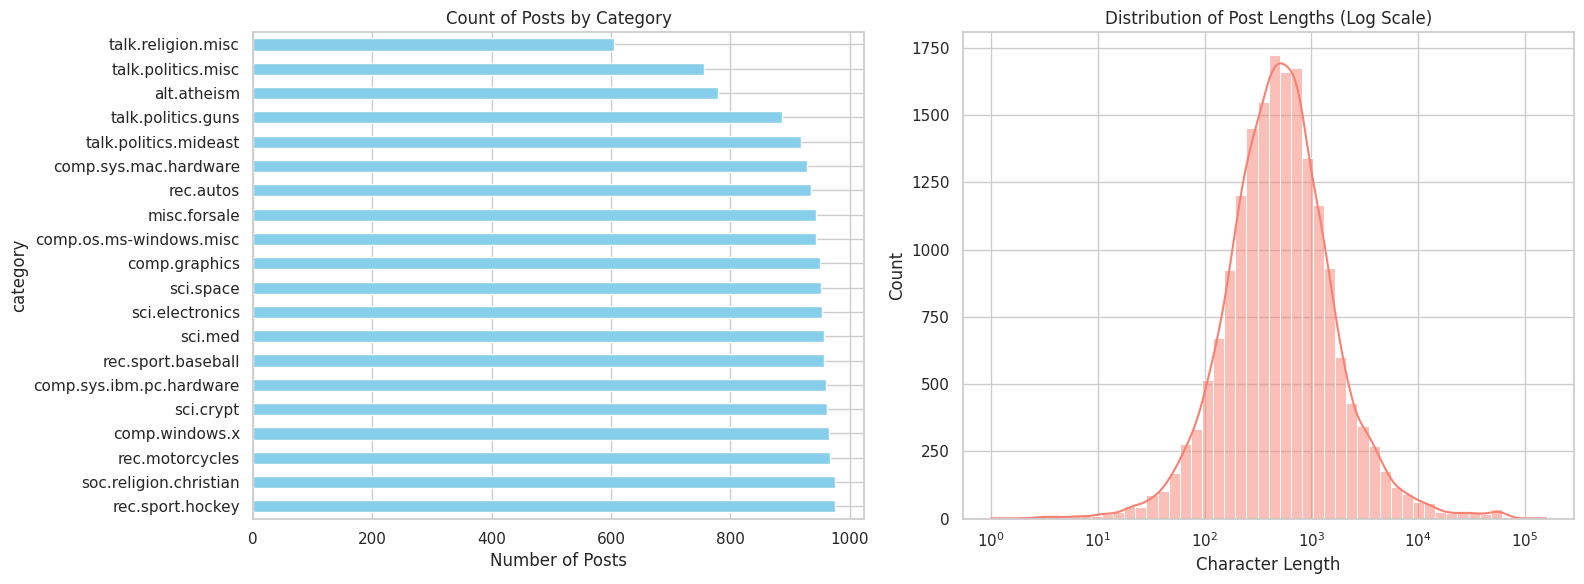

Top Category: rec.sport.hockey
Median Post Length: 503.0 characters


In [3]:
# Create EDA Visuals
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Visual 1: Distribution of News Categories
df['category'].value_counts().plot(kind='barh', ax=axes[0], color='skyblue')
axes[0].set_title('Count of Posts by Category')
axes[0].set_xlabel('Number of Posts')

# Visual 2: Distribution of Post Lengths
# Decision: We log-transform the x-axis because text lengths are highly skewed
sns.histplot(df['text_len'], bins=50, kde=True, ax=axes[1], log_scale=True, color='salmon')
axes[1].set_title('Distribution of Post Lengths (Log Scale)')
axes[1].set_xlabel('Character Length')

plt.tight_layout()
plt.show()

# Initial Observation:
print(f"Top Category: {df['category'].value_counts().idxmax()}")
print(f"Median Post Length: {df['text_len'].median()} characters")

## (D) Exploratory Data Analysis Observations

The EDA performed above reveals several key properties of the 20 Newsgroups dataset:

1.  **Category Distribution:** The bar chart shows that the dataset is remarkably well-balanced. While `rec.sport.hockey` is the most frequent category, most categories hover around 800-900 posts. This balance is ideal for clustering and classification because the model will not be overly biased toward one specific topic.
2.  **Text Length Distribution:** The histogram (Log Scale) shows that post lengths follow a roughly log-normal distribution. The median post length is **503 characters**.
3.  **Data Sparsity/Noise:** The wide tail in the length distribution (extending to $10^5$ characters) suggests that some posts are extremely long, likely containing system logs or large datasets. Conversely, the posts on the left (under 10 characters) are likely "noise" or one-word replies that should be filtered before mining.
4.  **Category Specificity:** The "Talk" and "Religion" categories are slightly less frequent than the "Comp" or "Sci" categories, which may affect the support thresholds used during frequent itemset mining.

## (E) Initial Insights and Direction

**Observation:**
The median post is quite short (approx. 500 characters), but the categories are diverse. The top category, `rec.sport.hockey`, likely contains many specific proper nouns (team names, player names) that differ significantly from the specialized vocabulary of `sci.crypt` or `comp.windows.x`.

**Hypothesis:**
I hypothesize that standard stop-word removal will not be enough to create clean clusters; we will likely need to implement **TF-IDF (Term Frequency-Inverse Document Frequency)** to down-weight common terms like "subject" or "post" that appear across all newsgroups.

**Potential Research Questions (RQs):**
*   **RQ1 (Course Technique - Clustering):** To what extent does the clustering accuracy (measured by ARI or NMI) improve when we filter out the extreme "outlier" posts (the top and bottom 5% of lengths) identified in our EDA?
*   **RQ2 (Beyond-Course - Topic Modeling):** Can **LDA (Latent Dirichlet Allocation)** distinguish between overlapping categories (like `talk.politics.misc` and `talk.politics.guns`) better than a standard K-Means clustering algorithm?

## (F) Portfolio and Declarations

**GitHub Repository:** https://github.com/davidvanderklay/Unsupervised-Learning-Newsgroups

**Collaboration Declaration:**
1.  **Collaborators:** None .
2.  **Web Sources:** None .
3.  **AI Tools:** Gemini was used to help structure blocks of the notebook and generate the code for plotting.
4.  **Citations:** Ni, J., Li, J., & McAuley, J. (2019). Justifying recommendations using distantly-labeled reviews and fine-grained aspects.